## Two-Step SARIMAX-ML Hybrid FX Prediction

#### - Forecasting the USD/KRW Exchange Rate with Macroeconomic Indicators

## 1. Data Loading and Preprocessing 

#### 1.1. Data Loading

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from scipy.stats import shapiro
from statsmodels.tsa.stattools import zivot_andrews
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel
from scipy.stats import binomtest

import warnings
warnings.filterwarnings('ignore')
from IPython.core.display import HTML

In [2]:
tickers = {
    'usdkrw':'USDKRW=X',
    'vix':'^VIX',
    'spy':'SPY',
    'kospi':'^KS11',
    'us10y_rate':'^TNX',
    'dxy':'DX-Y.NYB',
    'wti':'CL=F',
    'usdcny':'USDCNY=X'}

raw = yf.download(
    list(tickers.values()),
    start='2009-12-01',
    end='2026-05-01',
    progress=False)

In [3]:
symbol_to_name = {v: k for k, v in tickers.items()}
df_raw = raw['Close'].rename(columns=symbol_to_name)

df_raw = df_raw.resample("ME").last()

df_raw['spy_ret']   = df_raw['spy'].pct_change()
df_raw['kospi_ret'] = df_raw['kospi'].pct_change()

df_raw = df_raw.dropna()

In [4]:
def load_finaeon(path, col_name, is_rate=False):
    raw = pd.read_csv(path, header=None, on_bad_lines='skip')
    
    header_row = raw[raw.iloc[:, 0] == 'Date'].index[0]

    data = raw.iloc[header_row + 1:, :4].copy()
    data.columns = ['Date', 'Ticker', 'Close', 'Annual_Percent_Change']
    
    data['Date']  = pd.to_datetime(data['Date'], format='%m/%d/%Y', errors='coerce')
    data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
    
    data = data.dropna(subset=['Date', 'Close'])
    data = data.set_index('Date').sort_index()

    s = data['Close'].resample('ME').last()
    
    if is_rate:
        s.name = col_name
        return s
    else:
        yoy = s.pct_change(12) * 100
        yoy.name = col_name
        return yoy

In [ ]:
us_cpi = load_finaeon(
    './USA_CPI_2009to2026_Monthly.csv',
    'us_cpi',
    is_rate = True
)
us_cpi = us_cpi['2010-01-01':]

kor_cpi = load_finaeon(
    './Korea CPI_2009to2026.csv',
    'kor_cpi'
)
kor_cpi = kor_cpi['2010-01-01':]

us_rate= load_finaeon(
    './USA Fed Funds Official Target Rate_2009to2026_daily.csv',
    'us_rate',
    is_rate = True
)
us_rate = us_rate['2010-01-01':]

kor_rate = load_finaeon(
    './Korea interest rate_2009to2026.csv',
    'kor_rate',
    is_rate = True
)
kor_rate = kor_rate['2010-01-01':]

In [ ]:
kor_cab = pd.read_csv('./kor_cab_2009to2026.csv')

kor_cab = kor_cab.iloc[[0]].copy()
kor_cab = kor_cab.T
kor_cab = kor_cab.iloc[1:].copy()
kor_cab.columns = ['kor_cab']

kor_cab.index = pd.to_datetime(kor_cab.index, format='%Y.%m')
kor_cab['kor_cab'] = pd.to_numeric(kor_cab['kor_cab'])

#### 1.2. Missing Values Handling and Resampling

In [7]:
df_raw = df_raw.join([us_cpi, kor_cpi, us_rate, kor_rate], how = 'left')

df_raw.loc['2025-10-31', 'us_cpi'] = 2.85
df_raw.loc['2026-04-30', 'us_cpi'] = 3.8
df_raw['cpi_diff'] = df_raw['us_cpi'] - df_raw['kor_cpi']
df_raw['rate_diff'] = df_raw['us_rate'] - df_raw['kor_rate']

The 2025-10 US CPI value was missing due to the US federal government shutdown, so it was imputed as the average of the 2025-09 and 2025-11 values.

The 2026-04 US CPI value was manually updated after the official release as the data was downloaded prior to the announcement.

In [8]:
kor_cab.index = kor_cab.index.to_period('M')
df_raw.index  = df_raw.index.to_period('M')

df_raw = df_raw.join(kor_cab, how='left')
df_raw.index = df_raw.index.to_timestamp('M')

In [9]:
df_raw = df_raw.drop(columns=['spy', 'kospi'])

As the `spy`, `kospi` series were transformed into returns, the original price columns were dropped.

In [ ]:
df_raw.isna().sum()

wti           0
dxy           0
usdcny        0
usdkrw        0
us10y_rate    0
vix           0
spy_ret       0
kospi_ret     0
us_cpi        0
kor_cpi       0
us_rate       0
kor_rate      0
cpi_diff      0
rate_diff     0
kor_cab       1
dtype: int64

In [11]:
df_raw.dropna(inplace=True)

In [12]:
y_raw = df_raw['usdkrw']
df_raw_x = df_raw.drop(columns = ['usdkrw'])

print(y_raw.shape)
print(df_raw_x.shape)

(195,)
(195, 14)


Due to excessive noise in the daily data monthly resampling was performed; any missing values arising from this process were subsequently dropped.

#### 1.3. Outlier Detection

In [13]:
z_scores = np.abs((np.log(df_raw['usdkrw']).diff() - np.log(df_raw['usdkrw']).diff().mean()) 
                  / np.log(df_raw['usdkrw']).diff().std())
print(np.log(df_raw['usdkrw']).diff()[z_scores > 3])  

Date
2011-09-30    0.093629
2016-03-31   -0.084792
Name: usdkrw, dtype: float64


Since the number of outliers was small (two observations) no additional outlier handling was applied and robust scaling was used instead to mitigate their impact.

#### 1.4. Target Variable Transformation

In [14]:
y_log = np.log(y_raw).diff().dropna()

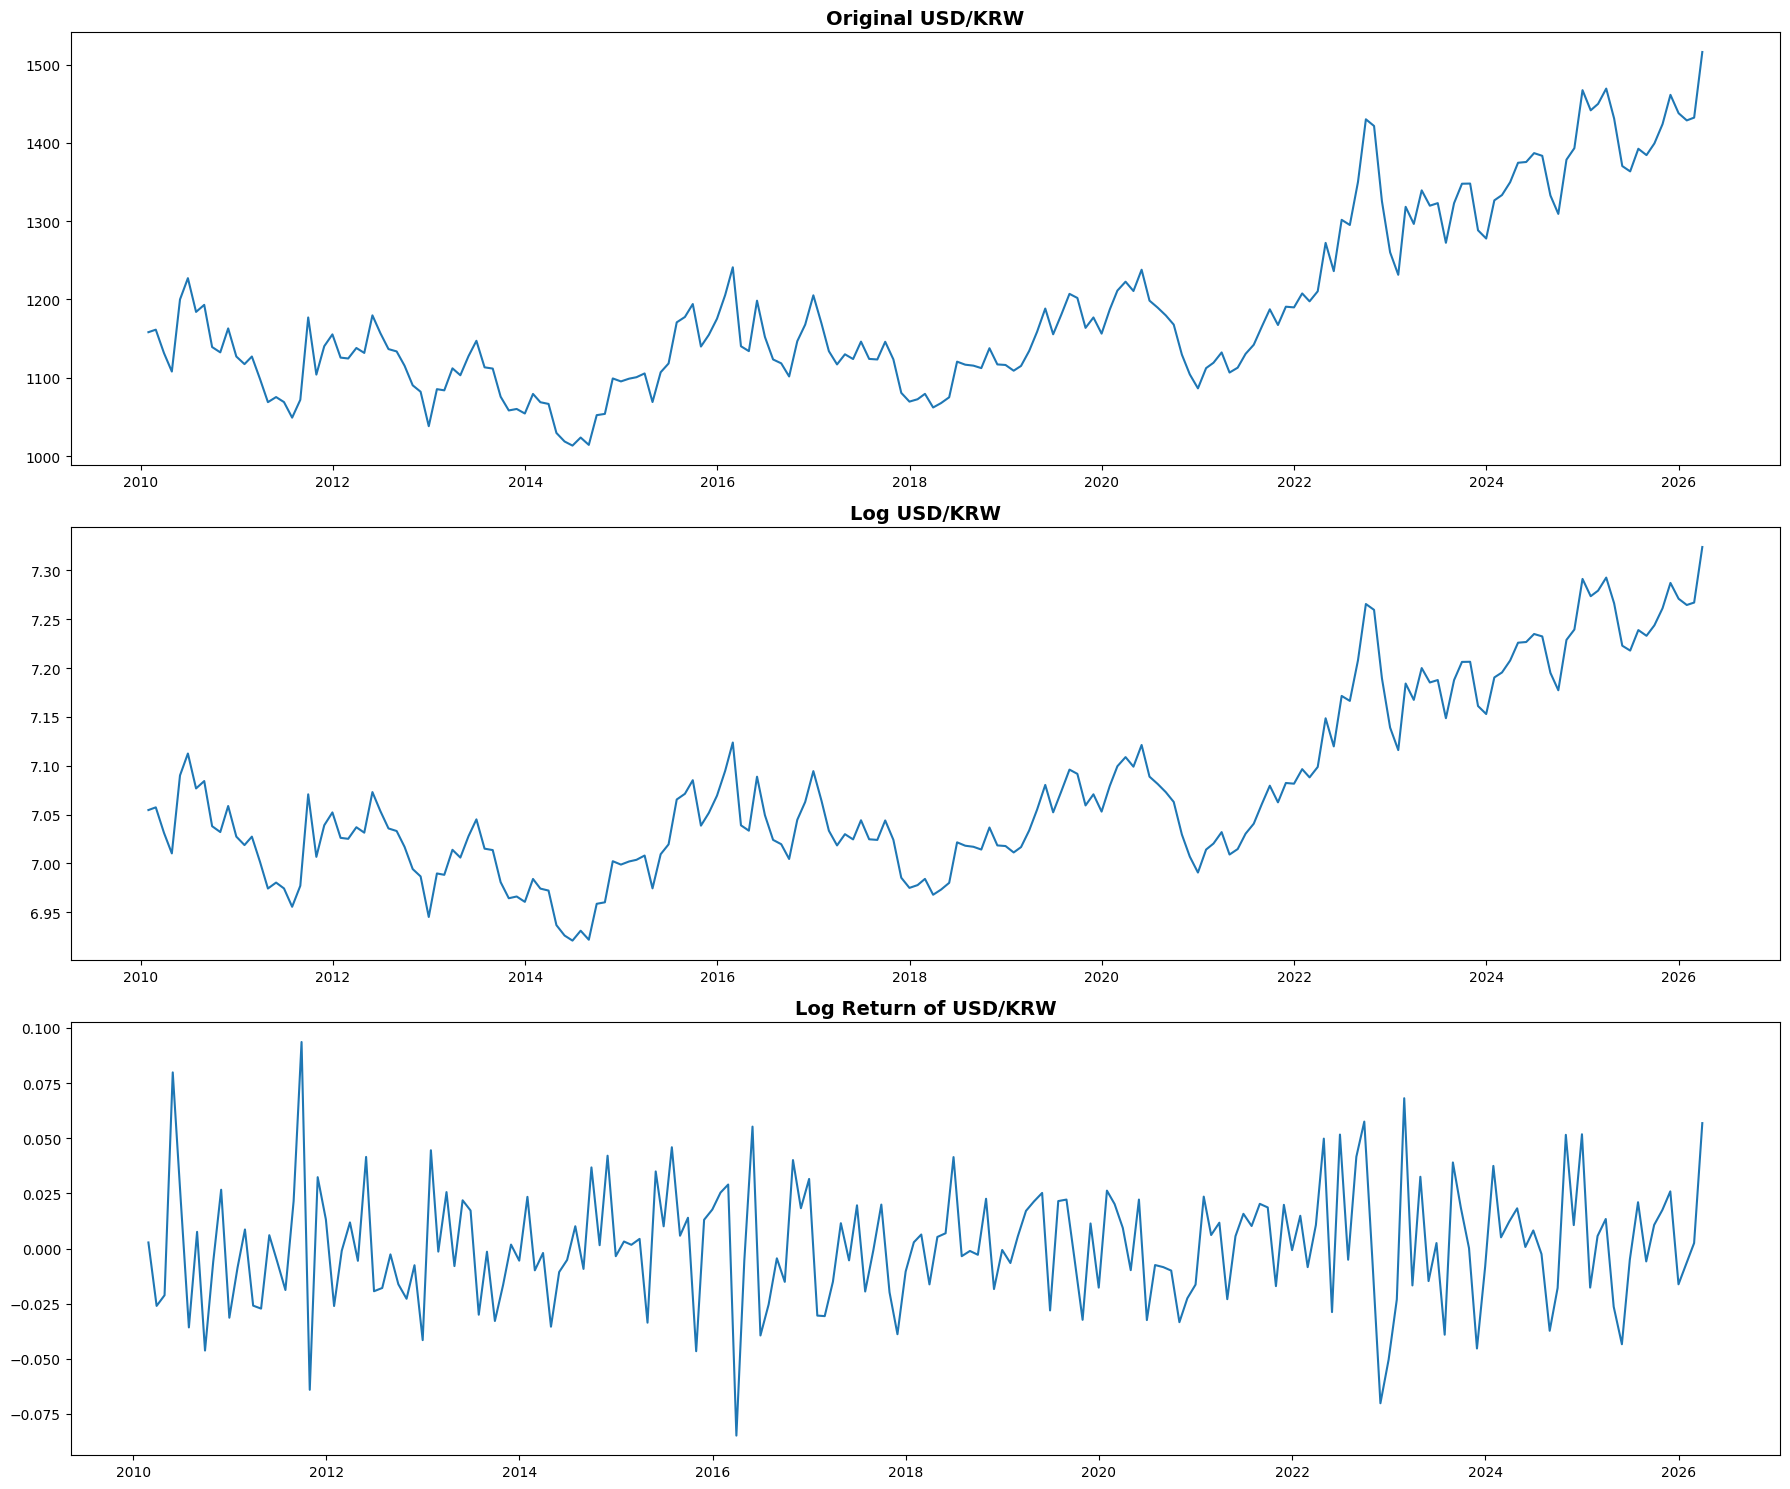

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

axes[0].plot(y_raw)
axes[0].set_title("Original USD/KRW", fontsize=14,fontweight='bold')

axes[1].plot(np.log(y_raw))
axes[1].set_title("Log USD/KRW", fontsize=14,fontweight='bold')

axes[2].plot(y_log)
axes[2].set_title("Log Return of USD/KRW", fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

To stabilize the variance, the target variable `usdkrw`  was transformed into the log return.

#### 1.5. Zivot-Andrews Test

In [16]:
y_za = np.log(y_raw).dropna()
za_stat, za_pval, za_cvs, za_baselag, za_basebreak = zivot_andrews(y_za,
    trim=0.15,
    regression='c'
)

print(f"ZA Statistic : {za_stat:.4f}")
print(f"Break point  : {y_za.index[za_basebreak]}")
print(f"Critical values: {za_cvs}")

ZA Statistic : -4.6478
Break point  : 2022-03-31 00:00:00
Critical values: {'1%': np.float64(-5.27644), '5%': np.float64(-4.81067), '10%': np.float64(-4.56618)}


The Zivot-Andrews test results identified March 2022 as the break point. This coincides with the start of the Russia-Ukraine war and the U.S. Federal Reserve’s interest rate hike cycle. 

Since the null hypothesis of a unit root could not be rejected at the 5% significance level (`ZA statistic = −4.811`) this result serves as additional evidence supporting the validity of the log return transformation

#### 1.6. Stationarity Test

In [17]:
results=[]

def stationarity_test(series, name):
    adf_result = adfuller(series.dropna(), autolag='AIC')
    adf_p = adf_result[1]
    
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_p = kpss_result[1]
    
    if adf_p < 0.05 and kpss_p > 0.05:
        return
    
    if adf_p >= 0.05 and kpss_p <= 0.05:
        conclusion = 'non-stationary'
    else:
        conclusion = 'uncertain'  
    
    results.append({
        'Variable'    : name,
        'ADF p-value' : round(adf_p, 4),
        'KPSS p-value': round(kpss_p, 4),
        'Conclusion'  : conclusion
    })

In [18]:
print("1st Stationarity Test")
for col in df_raw_x.columns:
    stationarity_test(df_raw_x[col], col)

result_df_raw = pd.DataFrame(results)
display(result_df_raw)

1st Stationarity Test


,Variable,ADF p-value,KPSS p-value,Conclusion
0,wti,0.1513,0.0651,uncertain
1,dxy,0.4380,0.0100,non-stationary
2,usdcny,0.3460,0.0100,non-stationary
3,us10y_rate,0.6252,0.0305,non-stationary
4,us_cpi,0.6205,0.0100,non-stationary
5,kor_cpi,0.1001,0.1000,uncertain
6,us_rate,0.2572,0.0100,non-stationary
7,kor_rate,0.2897,0.1000,uncertain
8,cpi_diff,0.6034,0.0100,non-stationary
9,rate_diff,0.8103,0.0100,non-stationary


To assess the stationarity of the target variable and 14 exogenous features, both the Augmented Dickey-Fuller test and the Kwiatkowski-Phillips-Schmidt-Shin test were applied.

The results of the initial stationarity test indicated that a total of seven exogenous variables were non-stationary, four were found to be uncertain, and the remaining three were found to be stationary.

#### 1.7. Differencing

In [19]:
df_x = df_raw_x.copy()
df_x['wti_rate'] = np.log(df_raw_x['wti']).diff()
df_x['usdcny_rate'] = np.log(df_raw_x['usdcny']).diff()

for col in ['dxy', 'us10y_rate','us_cpi','kor_cpi','us_rate','kor_rate', 'cpi_diff','rate_diff','kor_cab']:
    df_x[f"{col}_diff"] = df_raw_x[col].diff()

In [20]:
df_x = df_x.drop(columns=['wti','dxy', 'us10y_rate','us_cpi','kor_cpi','us_rate','kor_rate', 'cpi_diff','rate_diff','usdcny','kor_cab'])
df_x = df_x.dropna()

The price variables (`wti_rate` and `usdcny_rate`) were transformed into log returns while the remaining exogenous variables were differenced.

In [21]:
print("2nd Stationarity Test")
results=[]

for col in df_x.columns:
    stationarity_test(df_x[col], col)

display(pd.DataFrame(results))

2nd Stationarity Test


,Variable,ADF p-value,KPSS p-value,Conclusion
0,us_cpi_diff,0.0,0.0417,uncertain
1,cpi_diff_diff,0.0,0.0417,uncertain


In [22]:
df_x.drop(columns=['cpi_diff_diff', 'rate_diff_diff'], inplace=True)

Since the second order differencing results showed no non-stationary variables, the process was concluded by dropping the variables that had been differenced twice (`cpi_diff_diff` and `rate_diff_diff`).

#### 1.8. Lag Feature Generation

In [23]:
df_x_lag = df_x.copy()
df_x_lag[df_x.columns] = df_x[df_x.columns].shift(1)
df_x_lag.dropna(inplace=True)

In [24]:
index = df_x_lag.index
y_log = y_log.loc[index]

print(len(df_x_lag), len(y_log))

193 193


Since the purpose of this project is forecasting, a lag of 1 was applied to all exogenous variables. Although methods exist for selecting the optimal lag order, all exogenous variables were uniformly lagged by one period to avoid excessive data loss that would arise from using heterogeneous lag lengths across variables.

## 2. Train-Test Split and Exogenous Variable Screening

#### 2.1. Train-Test Split

In [25]:
split_idx = int(len(df_x_lag) * 0.8)

X_train = df_x_lag.iloc[:split_idx]
X_test = df_x_lag.iloc[split_idx:]

y_train = y_log.iloc[:split_idx]
y_test = y_log.iloc[split_idx:]

In [26]:
print(f"{X_train.index[0]} to {X_train.index[-1]}, {X_train.shape}")
print(f"{X_test.index[0]} to {X_test.index[-1]}, {X_test.shape}")

2010-03-31 00:00:00 to 2022-12-31 00:00:00, (154, 12)
2023-01-31 00:00:00 to 2026-03-31 00:00:00, (39, 12)


#### 2.2. CCF Analysis

In [27]:
for col in X_train.columns:
    cc = ccf(X_train[col].dropna(), y_train.dropna(), nlags=4)
    print(f"{col}: lag1={cc[0]:.4f}")

vix: lag1=-0.0796
spy_ret: lag1=0.0960
kospi_ret: lag1=-0.0375
wti_rate: lag1=0.0232
usdcny_rate: lag1=-0.0329
dxy_diff: lag1=-0.0396
us10y_rate_diff: lag1=-0.0047
us_cpi_diff: lag1=0.0615
kor_cpi_diff: lag1=0.1439
us_rate_diff: lag1=0.0569
kor_rate_diff: lag1=-0.0725
kor_cab_diff: lag1=-0.0059


In [28]:
print(f"{1.96/np.sqrt(len(X_train)):.4f}")
ccf_threshold = 1.96/np.sqrt(len(X_train))

cols_ccf = []
for col in X_train.columns:
    cc = ccf(X_train[col].dropna(), y_train.dropna(), nlags=4)
    if abs(cc[0]) > ccf_threshold:
        cols_ccf.append(col)

print(cols_ccf)

0.1579
[]


The results of the cross-correlation function analysis between each variable and y at lag = 1 are shown above. The analysis uses an approximate significance threshold of $\frac{z}{\sqrt{n}}$,  where `z=1.96` corresponds to the 97.5th percentile of the standard normal distribution equivalent to a two-sided significance level of 5%.


No variables were selected under the 5% significance threshold indicating that none of the macroeconomic variables exhibit a statistically significant linear relationship with the USD/KRW log return at a one-period lag. Accordingly, CCF based variable screening is deemed insufficient for meaningful feature selection suggesting that short term linear leading indicators among the candidate macroeconomic variables are absent.

#### 2.3. Multicollinearity Check for Exogenous Variables

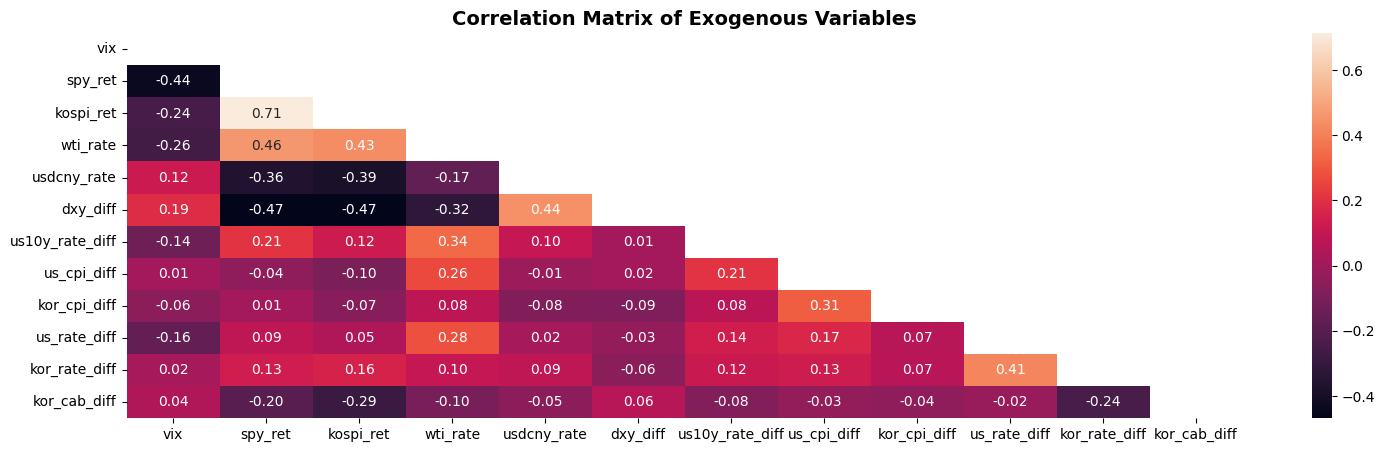

In [29]:
plt.figure(figsize = (18,5))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f')
plt.title("Correlation Matrix of Exogenous Variables", fontsize=14,fontweight='bold')
plt.show()

In [30]:
vif = pd.DataFrame()
vif['feature'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) 
              for i in range(X_train.shape[1])]

print(vif.sort_values(by='VIF', ascending=False))

            feature       VIF
2         kospi_ret  2.554683
1           spy_ret  2.293137
3          wti_rate  1.718649
7       us_cpi_diff  1.697350
5          dxy_diff  1.544741
0               vix  1.492177
4       usdcny_rate  1.441593
10    kor_rate_diff  1.358868
9      us_rate_diff  1.354387
6   us10y_rate_diff  1.233042
11     kor_cab_diff  1.182837
8      kor_cpi_diff  1.150759


Since all VIF values are below 5, I will retain all features in the model.

#### 2.4. Feature Scaling

In [31]:
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.describe().round(2)

,vix,spy_ret,kospi_ret,wti_rate,usdcny_rate,dxy_diff,us10y_rate_diff,us_cpi_diff,kor_cpi_diff,us_rate_diff,kor_rate_diff,kor_cab_diff
count,154.00,154.00,154.00,154.00,154.00,154.00,154.00,154.00,154.00,154.00,154.00,154.00
mean,0.25,-0.12,-0.08,-0.14,0.13,-0.02,-0.10,0.11,0.02,0.02,0.01,0.02
std,0.89,0.86,0.88,0.98,1.06,0.72,0.91,0.82,0.78,0.19,0.12,0.81
min,-0.94,-2.87,-2.76,-6.41,-2.99,-2.22,-2.47,-1.94,-1.93,-1.50,-0.50,-2.20
25%,-0.40,-0.61,-0.53,-0.63,-0.46,-0.54,-0.64,-0.44,-0.43,0.00,0.00,-0.54
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.60,0.39,0.47,0.37,0.54,0.46,0.36,0.56,0.57,0.00,0.00,0.46
max,4.55,2.21,2.63,4.93,4.15,1.70,2.60,3.27,1.87,0.75,0.50,2.72


## 3. Box-Jenkins Modeling

#### 3.1. ACF and PACF

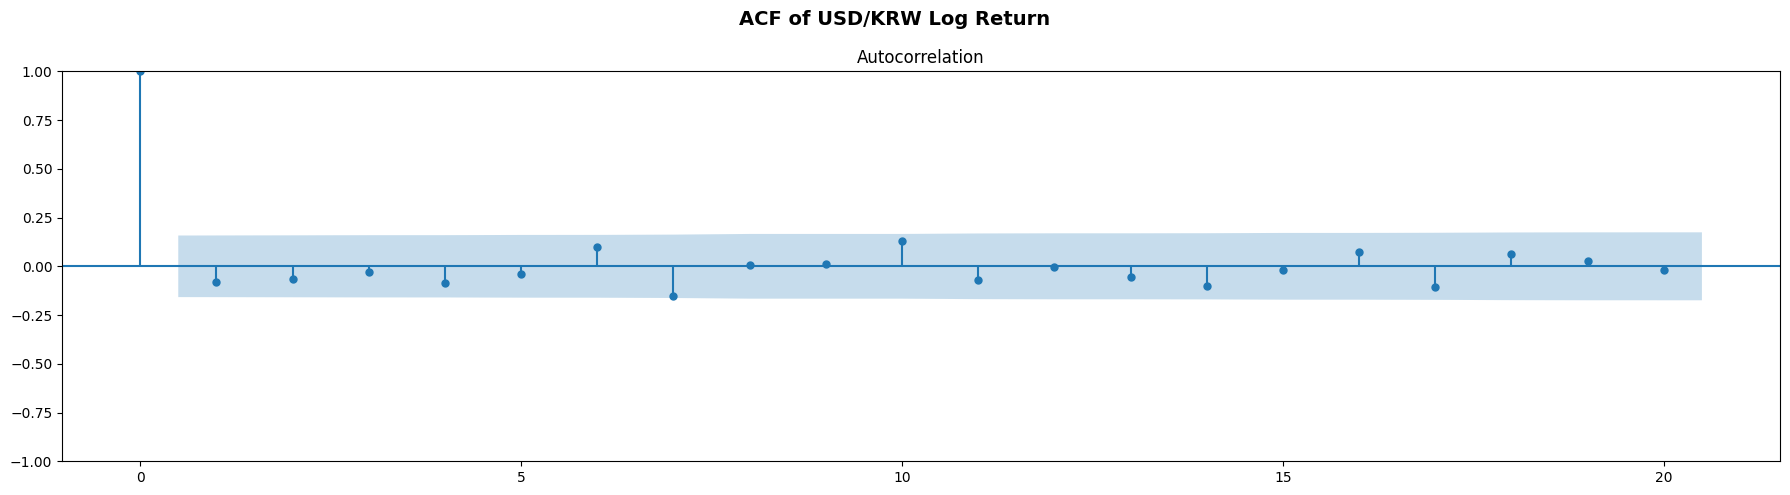

In [32]:
fig, ax = plt.subplots(figsize=(18, 5))
fig.suptitle("ACF of USD/KRW Log Return", fontsize=14, fontweight='bold')

plot_acf(y_train.dropna(), ax=ax, lags=20)

plt.tight_layout()
plt.show()

The ACF from lag 1 onward falls within the 95% confidence bounds indicating that the log return series exhibits no statistically significant autocorrelation and is consistent with a white noise process.

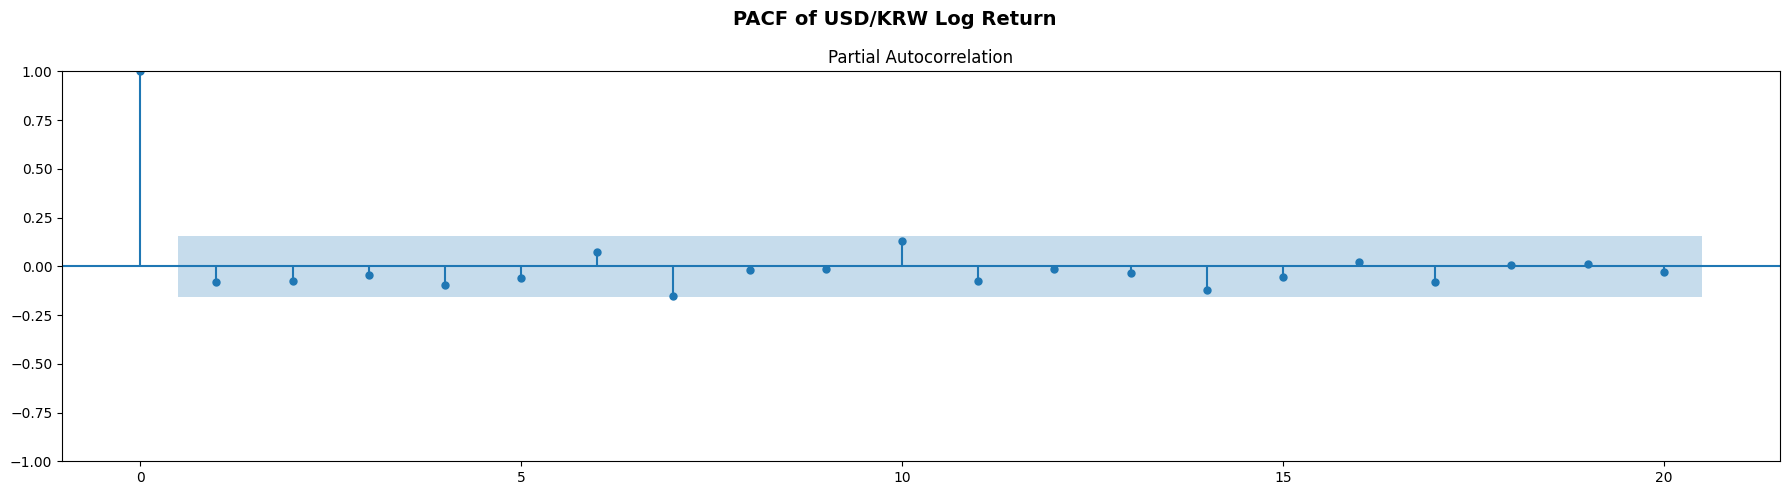

In [33]:
fig, ax = plt.subplots(figsize=(18, 5))
fig.suptitle("PACF of USD/KRW Log Return", fontsize=14, fontweight='bold')

plot_pacf(y_train.dropna(), ax=ax, lags=20, method='ywm')

plt.tight_layout()
plt.show()

The PACF from lag 1 onward falls within the 95% confidence bounds indicating that the log return series exhibits no statistically significant partial autocorrelation and is consistent with a white noise process.

In [34]:
result = adfuller(y_train.dropna())
p_value = result[1]
print(f"ADF p-value: {p_value:.4f}")

ADF p-value: 0.0000


The ADF test rejects the null hypothesis of a unit root at all conventional significance levels, thereby confirming that the USD/KRW log return series is stationary.

#### 3.2. SARIMAX Parameter Estimation

In [35]:
p_range = range(0, 5)
q_range = range(0, 5)
P_range = range(0, 2)
Q_range = range(0, 2)

best_aic = np.inf
best_bic = np.inf
best_aicc = np.inf

results=[]

for p, q, P, Q in itertools.product(p_range, q_range, P_range, Q_range):
    try:
        model = SARIMAX(y_train, exog=X_train_scaled, order=(p, 0, q), seasonal_order=(P, 0, Q, 12))
        result = model.fit(disp=False)

        k = len(result.params)
        n = len(y_train)
        aicc = result.aic + (2*k*(k+1)) / (n - k - 1)

        results.append({
            'p': p, 'q': q, 'P': P, 'Q': Q,
            'AIC' : round(result.aic, 4),
            'BIC' : round(result.bic, 4),
            'AICc': round(aicc, 4)
        })

    except:
        continue

results_df = pd.DataFrame(results).sort_values('AICc')
display(results_df.head(10))

,p,q,P,Q,AIC,BIC,AICc
24,1,1,0,0,-670.2323,-624.6780,-666.7540
28,1,2,0,0,-667.4188,-618.8275,-663.4480
26,1,1,1,0,-666.9603,-618.3690,-662.9895
44,2,1,0,0,-665.8454,-617.2542,-661.8746
27,1,1,1,1,-665.9819,-614.3537,-661.4819
30,1,2,1,0,-665.3503,-613.7221,-660.8503
25,1,1,0,1,-664.4654,-615.8742,-660.4946
45,2,1,0,1,-664.4666,-612.8384,-659.9666
8,0,2,0,0,-663.2813,-617.7270,-659.8030
48,2,2,0,0,-664.0936,-612.4654,-659.5936


The SARIMAX parameter estimation resulted in a selected specification of SARIMAX(1,0,1)(0,0,0). 

The corrected AIC, rather than the standard AIC, was used as the selection criterion because the sample size is relatively small due to the monthly frequency of the data. The corrected AIC provides a bias correction to AIC in small sample settings leading to a more reliable model selection.

#### 3.3. Model Selection

In [36]:
best = results_df.iloc[0]
best_model = SARIMAX(y_train, exog=X_train_scaled, 
                     order = (int(best['p']), 0, int(best['q'])),
                     seasonal_order=(int(best['P']), 0, int(best['Q']), 12))

best_result = best_model.fit(disp=False)
summary_text = best_result.summary().as_text()
HTML(f"<pre>{summary_text}</pre>")


The AR(1) and MA(1) terms are both statistically significant (p < 0.001), with coefficients of `0.6006` and `−0.9363`, respectively. This suggests that the ARMA structure adequately captures the serial dependence in the target series.

## 4. Diagnostic Checking

#### 4.1. Residual ACF

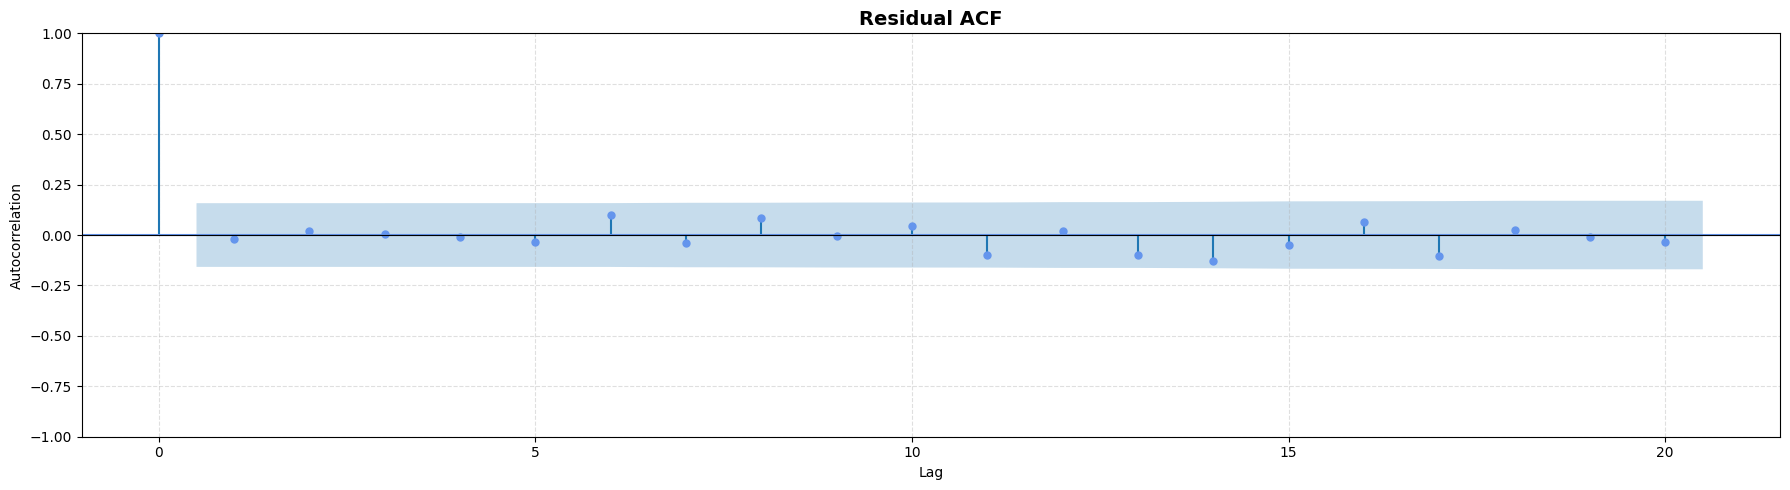

In [37]:
fig, ax = plt.subplots(figsize=(18, 5))
plot_acf(best_result.resid.dropna(), lags=20, ax=ax, color='cornflowerblue')
ax.set_title("Residual ACF", fontsize=14, fontweight='bold')
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.axhline(y=0, color='black', linewidth=0.8)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The ACF from lag 1 onward lies within the 95% confidence bounds, suggesting that the residuals behave like white noise and no significant serial correlation remains in the model errors.


#### 4.2. Ljung-Box Test

In [38]:
ljung = acorr_ljungbox(best_result.resid, lags=12)
print(ljung)

     lb_stat  lb_pvalue
1   0.055091   0.814430
2   0.105810   0.948470
3   0.110142   0.990593
4   0.123263   0.998177
5   0.313344   0.997385
6   1.931844   0.925859
7   2.202111   0.947812
8   3.412448   0.905877
9   3.420109   0.945291
10  3.730667   0.958680
11  5.459941   0.906866
12  5.533135   0.937767


The Ljung–Box test yields high p-values across all lags indicating no significant autocorrelation in the residuals and supporting the white noise assumption.

#### 4.3. Q-Q Plot

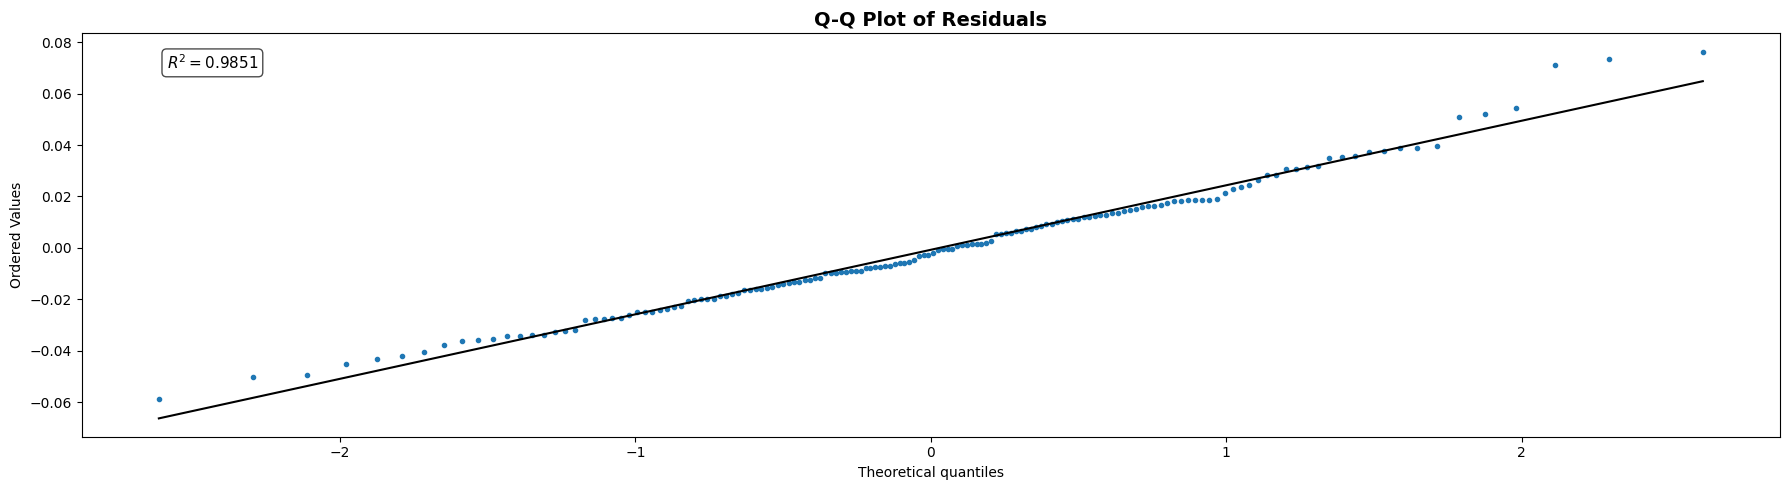

In [39]:
fig, ax = plt.subplots(figsize=(18, 5))

(osm, osr), (slope, intercept, r) = stats.probplot(best_result.resid.dropna(), dist="norm", plot=ax)
ax.text(0.05, 0.95, f'$R^2 = {r ** 2:.4f}$',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.set_title("Q-Q Plot of Residuals", fontsize=14,fontweight='bold')
ax.get_lines()[0].set(color='C0', markersize=3)
ax.get_lines()[1].set(color='black')

plt.tight_layout()
plt.show()

The Q-Q plot shows that the residuals are generally consistent with normality but deviations at both tails suggest heavier tails than a normal distribution. This is further confirmed by the Shapiro–Wilk test.

#### 4.4. Shapiro-Wilk Test

In [40]:
w, p = shapiro(best_result.resid.dropna())
print(f"w = {w:.4f}\np = {p:.4f}")

w = 0.9851
p = 0.0963


The Shapiro–Wilk test yields `W = 0.9851`, close to 1, with a p-value of `0.0963`. The null hypothesis of normality is not rejected at the 5% significance level indicating approximate normality of the residuals.

## 5. Forecasting and Evaluation

#### 5.1. Non-Rolling Forecast

In [41]:
pred = best_result.forecast(steps=len(y_test), exog=X_test_scaled)

last_log_price = np.log(y_raw).loc[y_train.index[-1]]
pred_price = np.exp(last_log_price + pred.cumsum())

actual_usd = y_raw.loc[y_test.index]
print(pred_price.head())
print(actual_usd.head())

2023-01-31    1264.714455
2023-02-28    1274.658930
2023-03-31    1284.725647
2023-04-30    1287.170105
2023-05-31    1284.168526
Freq: ME, Name: predicted_mean, dtype: float64
Date
2023-01-31    1231.500000
2023-02-28    1318.349976
2023-03-31    1296.500000
2023-04-30    1339.390015
2023-05-31    1319.790039
Freq: ME, Name: usdkrw, dtype: float64


#### 5.2. Rolling Forecast

In [42]:
pred_rolling = []


for i in range(len(y_test)):
    y_train_roll = pd.concat([y_train, y_test.iloc[:i]])
    X_train_roll = pd.concat([X_train_scaled, X_test_scaled.iloc[:i]])
    
    model_roll = SARIMAX(y_train_roll,
                         exog=X_train_roll,
                         order=(int(best['p']), 0, int(best['q'])),
                         seasonal_order=(int(best['P']), 0, int(best['Q']), 12))
    result_roll = model_roll.fit(disp=False)
    pred = result_roll.forecast(steps=1, exog=X_test_scaled.iloc[[i]])
    pred_rolling.append(pred.values[0])

pred_rolling = pd.Series(pred_rolling, index=y_test.index)

In [43]:
log_actual = np.log(y_raw)

pred_price_rolling = []

for i, pred_logret in enumerate(pred_rolling):
    if i == 0:
        prev_log = log_actual.loc[y_train.index[-1]]
    else:
        prev_log = log_actual.loc[y_test.index[i-1]]
    
    pred_price_rolling.append(np.exp(prev_log + pred_logret))

pred_price_rolling = pd.Series(pred_price_rolling, index=y_test.index)
actual_price = y_raw.loc[y_test.index]

#### 5.3. Rolling + Clipping Forecast

In [44]:
print(pred_rolling[pred_rolling.abs() > 0.05])

lower_bound = y_train.quantile(0.05)
upper_bound = y_train.quantile(0.95)
print(f"Clipping range: [{lower_bound:.4f}, {upper_bound:.4f}]")

Date
2025-11-30   -1.302333
Freq: ME, dtype: float64
Clipping range: [-0.0390, 0.0430]


To mitigate the impact of extreme values a 5% clipping threshold was applied to the test data. One observation on `2025-11-30` was identified as an outlier exceeding the clipping range of `[-0.0390, 0.0430]`. 

This is consistent with the sharp USD/KRW spike triggered by the short lived martial law declaration in South Korea on December 3, 2024, which induced extreme volatility in the won. The corresponding value was clipped to the boundary of the training distribution to ensure model stability.

In [45]:
pred_rolling2 = pred_rolling.clip(lower=lower_bound, upper=upper_bound)

pred_price_rolling2 = []
for i, pred_logret in enumerate(pred_rolling2):
    if i == 0:
        prev_log = log_actual.loc[y_train.index[-1]]
    else:
        prev_log = log_actual.loc[y_test.index[i-1]]
    pred_price_rolling2.append(np.exp(prev_log + pred_logret))

pred_price_rolling2 = pd.Series(pred_price_rolling2, index=y_test.index)

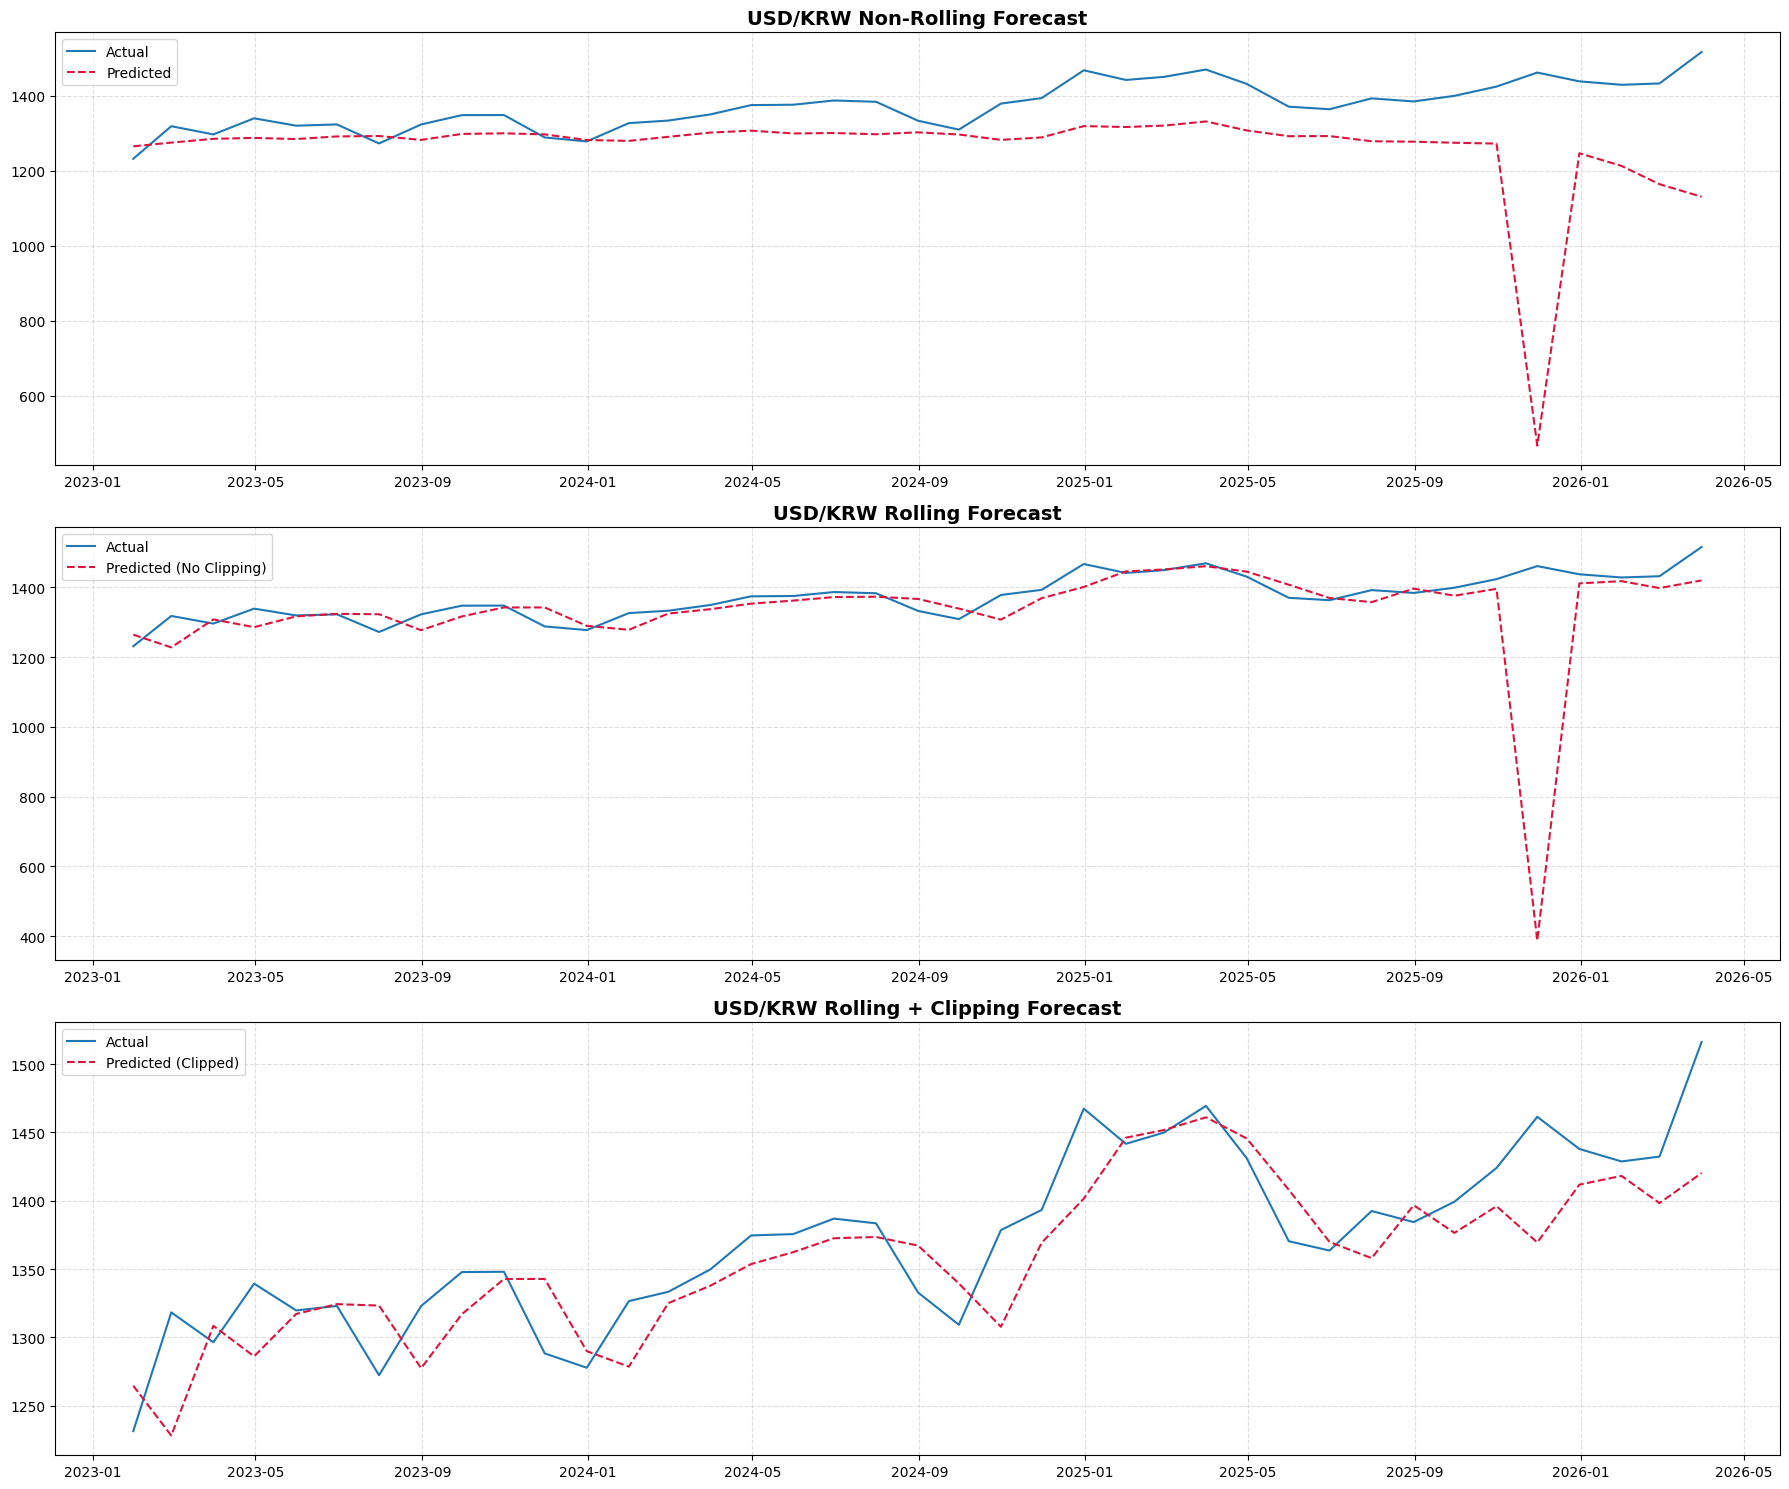

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

axes[0].plot(actual_usd, label='Actual', color='C0')
axes[0].plot(pred_price, label='Predicted', color='crimson', linestyle='--')
axes[0].set_title("USD/KRW Non-Rolling Forecast", fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(actual_price, label='Actual', color='C0')
axes[1].plot(pred_price_rolling, label='Predicted (No Clipping)', color='crimson', linestyle='--')
axes[1].set_title("USD/KRW Rolling Forecast", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].plot(actual_price, label='Actual', color='C0')
axes[2].plot(pred_price_rolling2, label='Predicted (Clipped)', color='crimson', linestyle='--')
axes[2].set_title(f"USD/KRW Rolling + Clipping Forecast", 
                  fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

The forecasting results across three specifications are shown in the plot above.

1. Non-rolling forecast: This approach exhibits the poorest performance and fails to capture the sharp movement observed at the end of 2025.

2. Rolling forecast: This method improves upon the non-rolling approach but still does not adequately reflect the extreme movement in late 2025.

3. Rolling + clipping forecast: By applying clipping to extreme values in late 2025, this approach successfully mitigates the impact of outliers and avoids the sharp downward distortion observed in the other two methods. Overall, this specification provides the most stable and accurate forecasts.

#### 5.4. Evaluation Metrics

In [47]:
def calc_metrics(actual, predicted, pred_logret, label):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    da   = np.mean(np.sign(pred_logret.values) == np.sign(y_test.values)) * 100
    
    print(f"[{label}]")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  Directional Accuracy: {da:.2f}%")
    print()

calc_metrics(actual_price, pred_price, pred, "Non-Rolling")
calc_metrics(actual_price, pred_price_rolling,  pred_rolling, "Rolilng")
calc_metrics(actual_price, pred_price_rolling2, pred_rolling2, "Rolling + Clipping")

[Non-Rolling]
  RMSE : 197.78
  MAE  : 114.22
  MAPE : 8.03%
  Directional Accuracy: 41.03%

[Rolilng]
  RMSE : 175.84
  MAE  : 55.25
  MAPE : 3.91%
  Directional Accuracy: 48.72%

[Rolling + Clipping]
  RMSE : 39.35
  MAE  : 30.07
  MAPE : 2.19%
  Directional Accuracy: 48.72%



In [48]:
rw_pred = actual_price.shift(1).dropna()
actual_rw = actual_price.loc[rw_pred.index]

rmse_rw = np.sqrt(mean_squared_error(actual_rw, rw_pred))
mae_rw  = mean_absolute_error(actual_rw, rw_pred)
mape_rw = np.mean(np.abs((actual_rw - rw_pred) / actual_rw)) * 100

print(f"[Random Walk]")
print(f"  RMSE : {rmse_rw:.2f}")
print(f"  MAE  : {mae_rw:.2f}")
print(f"  MAPE : {mape_rw:.2f}%")
print("  Directional Accuracy: 50% (Theoretical Baseline)")

[Random Walk]
  RMSE : 37.65
  MAE  : 29.19
  MAPE : 2.13%
  Directional Accuracy: 50% (Theoretical Baseline)


The SARIMAX model fails to outperform the Random Walk benchmark, which is consistent with the seminal finding of Meese & Rogoff (1983) that structural models cannot systematically beat a Random Walk in out-of-sample exchange rate forecasting.

## 6. ML Hybrid Modeling

In [49]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(154, 12)
(39, 12)


In [50]:
residual = best_result.resid
tscv = TimeSeriesSplit(n_splits=3)

`TimeSeriesSplit(n_splits=3)` was chosen to balance robustness and data efficiency under a limited sample size while reducing overfitting in the residual learning stage.

#### 6.1. LGBM

In [51]:
params_lgb={
  'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100],
    'num_leaves': [5, 7, 10],
    'min_data_in_leaf': [10, 15, 20],
    'max_depth': [2, 3, 4, 5]
    }

lgb = LGBMRegressor(verbose=-1)
search_lgb = RandomizedSearchCV(lgb, params_lgb, n_iter=30, 
                                cv=tscv, scoring='neg_mean_squared_error',
                                random_state=2026)
search_lgb.fit(X_train_scaled, residual)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=LGBMRegressor(verbose=-1), n_iter=30,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_data_in_leaf': [10, 15, 20],
                                        'n_estimators': [50, 100],
                                        'num_leaves': [5, 7, 10]},
                   random_state=2026, scoring='neg_mean_squared_error')

All three ML models were trained using `neg_mean_squared_error` as the optimization criterion where a less negative score corresponds to lower prediction error. This ensures consistency in model comparison and directly aligns the training objective with minimizing forecast error.

In [52]:
best_lgb = search_lgb.best_estimator_
print('LGBM Best Hyperparameters:')
for param, value in search_lgb.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nLGBM Best RMSE: {np.sqrt(- search_lgb.best_score_):.4f}")
null_rmse = residual.std()

LGBM Best Hyperparameters:
   num_leaves: 5
   n_estimators: 50
   min_data_in_leaf: 20
   max_depth: 2
   learning_rate: 0.01

LGBM Best RMSE: 0.0240


In [53]:
pred_lgb = best_lgb.predict(X_test_scaled)
pred_lgb = pd.Series(pred_lgb, index=y_test.index)

In [54]:
pred_combined_lgb = pred_rolling2 + pred_lgb
pred_combined_price_lgb = []

for i, pred_logret in enumerate(pred_combined_lgb):
    if i == 0:
        prev_log = log_actual.loc[y_train.index[-1]]
    else:
        prev_log = log_actual.loc[y_test.index[i-1]]
    pred_combined_price_lgb.append(np.exp(prev_log + pred_logret))

pred_combined_price_lgb = pd.Series(pred_combined_price_lgb, index=y_test.index)

#### 6.2. Support Vector Regression

In [55]:
params_svr = {
    'C': [0.1, 1.0, 10, 100],
    'epsilon': [0.001, 0.01, 0.05, 0.1],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}


svr = SVR(max_iter=10000)
search_svr = RandomizedSearchCV(svr, params_svr, n_iter=20, 
                                cv=tscv, scoring='neg_mean_squared_error',
                                random_state=2026)
search_svr.fit(X_train_scaled, residual)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=SVR(max_iter=10000), n_iter=20,
                   param_distributions={'C': [0.1, 1.0, 10, 100],
                                        'epsilon': [0.001, 0.01, 0.05, 0.1],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['rbf', 'linear']},
                   random_state=2026, scoring='neg_mean_squared_error')

In [56]:
best_svr = search_svr.best_estimator_
print('SVR Best Hyperparameters:')
for param, value in search_svr.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nSVR Best RMSE: {np.sqrt(- search_svr.best_score_):.4f}")

SVR Best Hyperparameters:
   kernel: rbf
   gamma: auto
   epsilon: 0.1
   C: 1.0

SVR Best RMSE: 0.0261


In [57]:
pred_svr = best_svr.predict(X_test_scaled)
pred_svr = pd.Series(pred_svr, index=y_test.index)

In [58]:
pred_combined_svr = pred_rolling2 + pred_svr
pred_combined_price_svr = []

for i, pred_logret in enumerate(pred_combined_svr):
    if i == 0:
        prev_log = log_actual.loc[y_train.index[-1]]
    else:
        prev_log = log_actual.loc[y_test.index[i-1]]
    pred_combined_price_svr.append(np.exp(prev_log + pred_logret))

pred_combined_price_svr = pd.Series(pred_combined_price_svr, index=y_test.index)

#### 6.3. Gaussian Process Regression

In [59]:
params_gpr = {
    'kernel': [
        RBF() + WhiteKernel(),
        Matern(nu=1.5) + WhiteKernel(),
        Matern(nu=2.5) + WhiteKernel(),
        RationalQuadratic() + WhiteKernel()
    ],
    'alpha': [1e-3, 1e-2, 1e-1]
}


gpr = GaussianProcessRegressor(normalize_y=True)
search_gpr = RandomizedSearchCV(gpr, params_gpr, n_iter=12, 
                                cv=tscv, scoring='neg_mean_squared_error',
                                random_state=2026)
search_gpr.fit(X_train_scaled, residual)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=GaussianProcessRegressor(normalize_y=True),
                   n_iter=12,
                   param_distributions={'alpha': [0.001, 0.01, 0.1],
                                        'kernel': [RBF(length_scale=1) + WhiteKernel(noise_level=1),
                                                   Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1),
                                                   Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1),
                                                   RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)]},
                   random_state=2026, scoring='neg_mean_squared_error')

In [60]:
best_gpr = search_gpr.best_estimator_
print('GPR Best Hyperparameters:')
for param, value in search_gpr.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nGPR Best RMSE: {np.sqrt(- search_gpr.best_score_):.4f}")

GPR Best Hyperparameters:
   kernel: Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1)
   alpha: 0.001

GPR Best RMSE: 0.0239


In [61]:
pred_gpr = best_gpr.predict(X_test_scaled)
pred_gpr = pd.Series(pred_gpr, index=y_test.index)

In [62]:
pred_combined_gpr = pred_rolling2 + pred_gpr
pred_combined_price_gpr = []

for i, pred_logret in enumerate(pred_combined_gpr):
    if i == 0:
        prev_log = log_actual.loc[y_train.index[-1]]
    else:
        prev_log = log_actual.loc[y_test.index[i-1]]
    pred_combined_price_gpr.append(np.exp(prev_log + pred_logret))

pred_combined_price_gpr = pd.Series(pred_combined_price_gpr, index=y_test.index)

#### 6.4. Hybrid Models Evaluation

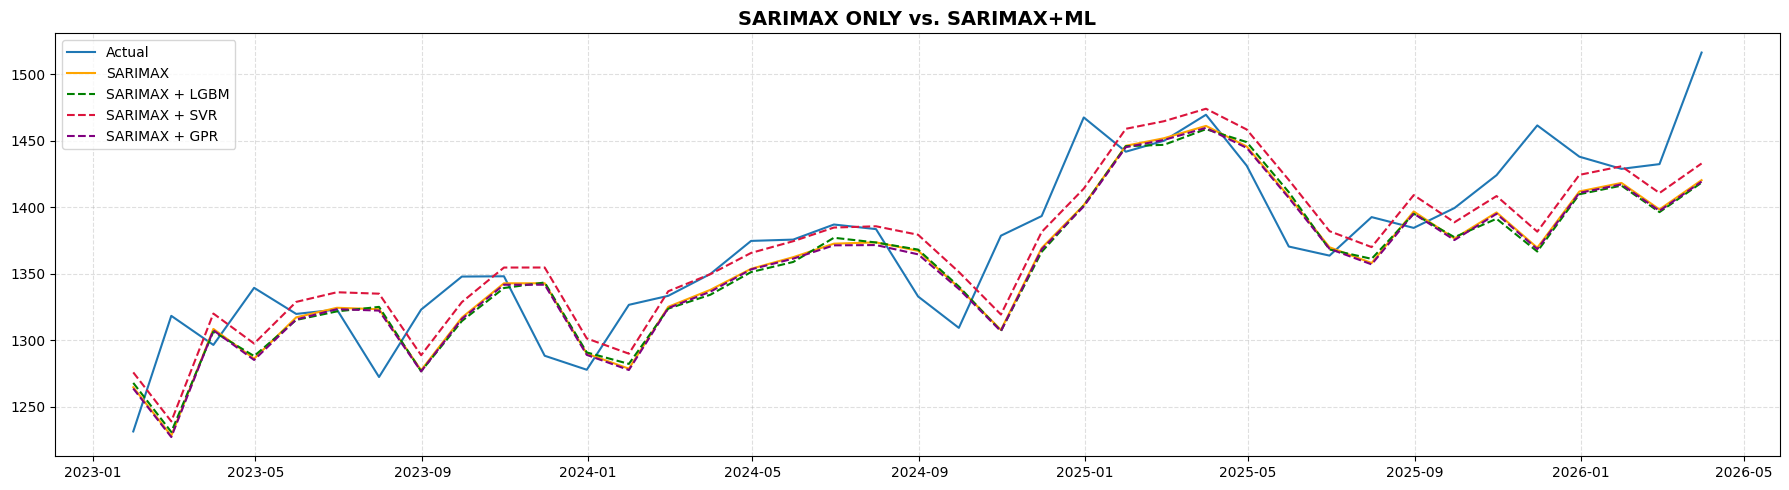

In [ ]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(actual_price, label='Actual', color='C0')
ax.plot(pred_price_rolling2, label='SARIMAX', color='orange')
ax.plot(pred_combined_price_lgb, label='SARIMAX + LGBM', color='green', linestyle='--')
ax.plot(pred_combined_price_svr, label='SARIMAX + SVR', color='crimson', linestyle='--')
ax.plot(pred_combined_price_gpr, label='SARIMAX + GPR', color='purple', linestyle='--')
ax.set_title("SARIMAX ONLY vs. SARIMAX+ML", fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [64]:
calc_metrics(actual_price, pred_combined_price_lgb, pred_combined_lgb, "SARIMAX + LGBM")
calc_metrics(actual_price, pred_combined_price_svr, pred_combined_svr, "SARIMAX + SVR")
calc_metrics(actual_price, pred_combined_price_gpr, pred_combined_gpr, "SARIMAX + GPR")

[SARIMAX + LGBM]
  RMSE : 39.99
  MAE  : 30.98
  MAPE : 2.25%
  Directional Accuracy: 51.28%

[SARIMAX + SVR]
  RMSE : 36.76
  MAE  : 28.14
  MAPE : 2.06%
  Directional Accuracy: 71.79%

[SARIMAX + GPR]
  RMSE : 39.70
  MAE  : 30.34
  MAPE : 2.21%
  Directional Accuracy: 48.72%



In [65]:
print(f"[Random Walk]")
print(f"  RMSE : {rmse_rw:.2f}")
print(f"  MAE  : {mae_rw:.2f}")
print(f"  MAPE : {mape_rw:.2f}%")
print("  Directional Accuracy: 50% (Theoretical Baseline)\n")
calc_metrics(actual_price, pred_price_rolling2, pred_rolling2, "SARIMAX only")

[Random Walk]
  RMSE : 37.65
  MAE  : 29.19
  MAPE : 2.13%
  Directional Accuracy: 50% (Theoretical Baseline)

[SARIMAX only]
  RMSE : 39.35
  MAE  : 30.07
  MAPE : 2.19%
  Directional Accuracy: 48.72%



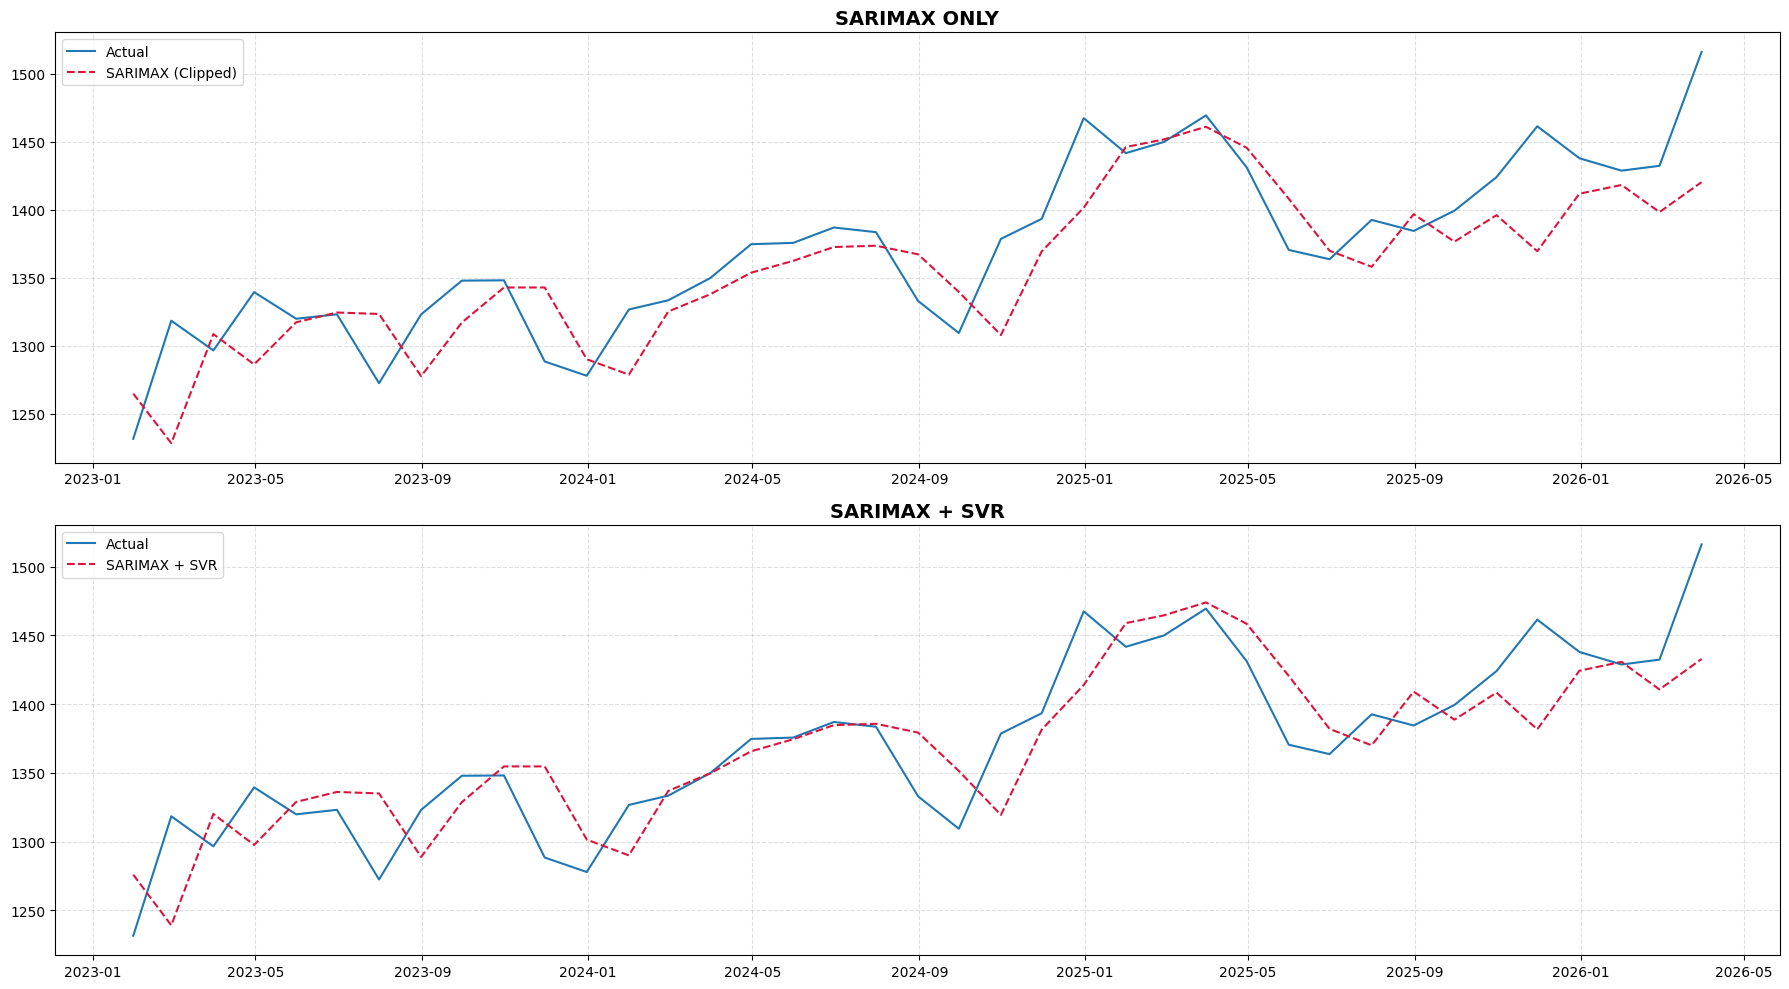

In [66]:
fig, axes = plt.subplots(2,1, figsize=(18,10))

axes[0].plot(actual_price, label='Actual', color='C0')
axes[0].plot(pred_price_rolling2, label='SARIMAX (Clipped)', color='crimson', linestyle='--')
axes[0].set_title("SARIMAX ONLY", fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(actual_price, label='Actual', color='C0')
axes[1].plot(pred_combined_price_svr, label='SARIMAX + SVR', color='crimson', linestyle='--')
axes[1].set_title("SARIMAX + SVR", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

SVR outperformed the Random Walk benchmark across all four evaluation metrics. However, given the small test sample size (n=39), a further step is conducted below to assess the statistical significance of the SARIMAX+SVR hybrid model’s performance.

#### 6.5. Statistical Significance of the SVR Hybrid Model

#### 6.5.1. Binomial Test

In [67]:
n = len(y_test)
correct_mask = np.sign(pred_combined_svr.values) == np.sign(y_test.values)
correct = correct_mask.sum()

result = binomtest(correct, n, p=0.5, alternative='greater')

print(f"The Number of Test Samples : {n}")
print(f"The Number of Successes: {correct}")
print(f"P-value : {result.pvalue:.4f}")

The Number of Test Samples : 39
The Number of Successes: 28
P-value : 0.0047


The binomial test results show 28 successes out of 39 test samples yielding a p-value of `0.0047` < 0.05. 

This indicates that the directional accuracy is statistically significantly greater than the 50% chance benchmark, suggesting that the model exhibits consistent predictive skill beyond random chance.

#### 6.5.2. Directional Prediction Plot

{'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.1, 'C': 1.0}


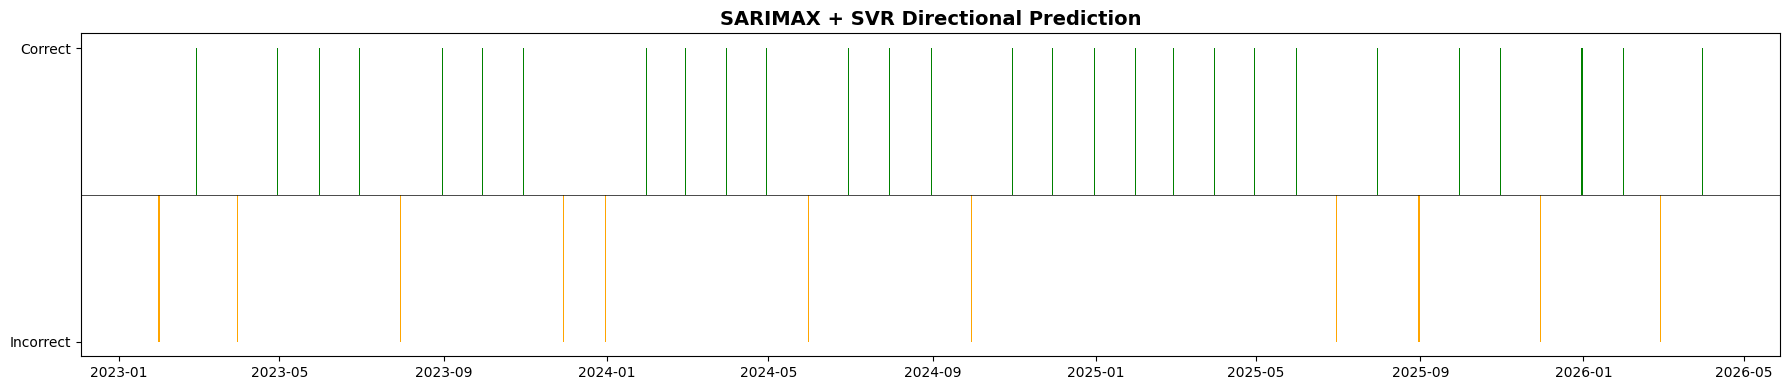

In [68]:
print(search_svr.best_params_)  
correct_mask = np.sign(pred_combined_svr.values) == np.sign(y_test.values)

heights = np.where(correct_mask, 1, -1)
fig, ax = plt.subplots(figsize=(18, 4))
ax.bar(y_test.index, heights, 
       color=['green' if c else 'orange' for c in correct_mask])

ax.axhline(0, color='black', linewidth=0.5)
ax.set_yticks([-1,1])
ax.set_yticklabels(['Incorrect', 'Correct'])
ax.set_title("SARIMAX + SVR Directional Prediction", fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

Correct and incorrect predictions are evenly distributed throughout the test period, indicating that the model does not display systematic time period specific bias.